<a href="https://colab.research.google.com/github/Kenny-W99/HeadCT-CNN/blob/main/Head_CT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.flush_and_unmount()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
import os
import cv2
import pickle
import math
import itertools
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, RandomizedSearchCV, validation_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_recall_curve, confusion_matrix, classification_report, auc, roc_curve, roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier, plot_importance
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow import keras
from keras import layers
import tensorflow_hub as hub
from keras.models import Sequential, Model
from keras.layers import Dense, Input, Flatten, Dropout, Conv2D, MaxPooling2D, SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D
from keras.applications.xception import Xception
from keras import applications
from keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.applications import ResNet50
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback, TensorBoard, CSVLogger, LearningRateScheduler
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from keras.layers import concatenate
from keras import backend as K
from tensorflow.keras.utils import plot_model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np, tensorflow as tf, os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Input, Resizing, Lambda, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import layers


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%matplotlib inline

In [ ]:
# to import the data
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
file_path = '/content/drive/MyDrive/SummerProject/labels.csv'
labels = pd.read_csv(file_path)
labels.rename(columns={' hemorrhage': 'hemorrhage'}, inplace=True)
label = np.array(labels.hemorrhage.tolist())


Mounted at /content/drive


<Axes: xlabel='height', ylabel='Count'>

<Axes: xlabel='height', ylabel='Count'>

,height,width
count,200.0,200.0
mean,128.0,128.0
std,0.0,0.0
min,128.0,128.0
25%,128.0,128.0
50%,128.0,128.0
75%,128.0,128.0
max,128.0,128.0


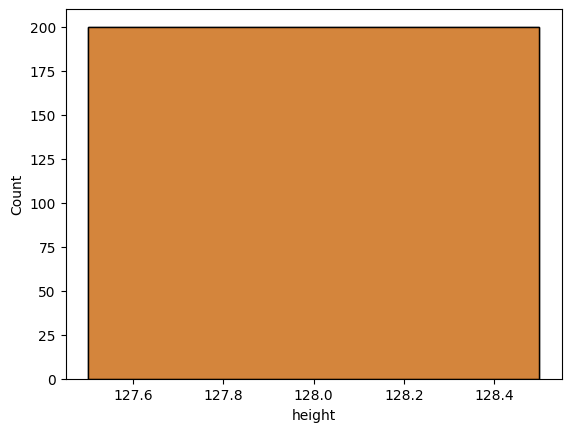

In [ ]:
# read abd make the sze the same
files = sorted(glob('/content/drive/My Drive/SummerProject/head_ct/*.png'))
images = np.array([cv2.resize(cv2.imread(p), (128, 128)) for p in files])

images_df = pd.DataFrame({'image': list(images)})
images_df['height']   = images_df['image'].map(lambda x: x.shape[0])
images_df['width']    = images_df['image'].map(lambda x: x.shape[1])
images_df['channels'] = images_df['image'].map(lambda x: x.shape[2] if x.ndim==3 else 1)

# Vitualization
sns.histplot(data=images_df, x='height')
sns.histplot(data=images_df, x='width')
images_df[['height','width']].describe()

In [ ]:
image_label = [images, label]

<Axes: xlabel='height', ylabel='Count'>

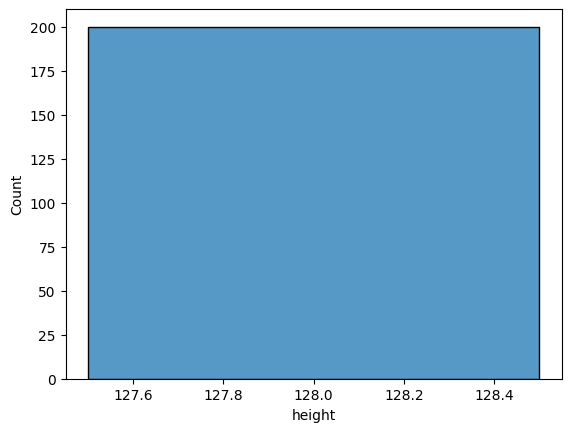

In [ ]:
# plot images width and height distribution
sns.histplot(data=images_df[['height', 'width']], x='height')

<Axes: xlabel='width', ylabel='Count'>

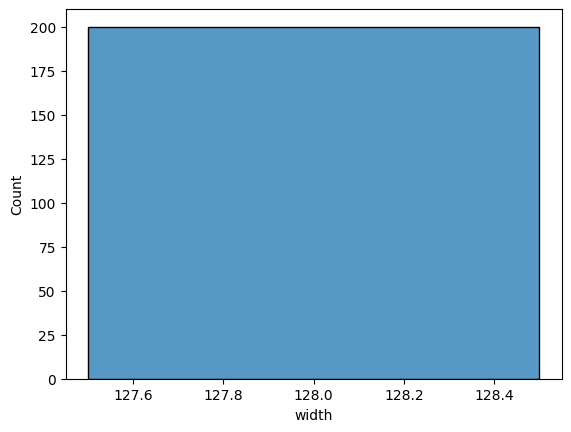

In [ ]:
sns.histplot(data=images_df[['height', 'width']], x='width')

In [ ]:
# get statitistics of height and width
images_df[['height', 'width']].describe()


,height,width
count,200.0,200.0
mean,128.0,128.0
std,0.0,0.0
min,128.0,128.0
25%,128.0,128.0
50%,128.0,128.0
75%,128.0,128.0
max,128.0,128.0


In [ ]:
# images have different sizes, making all images the same size
images = np.array([cv2.resize(image, (128, 128)) for image in images])

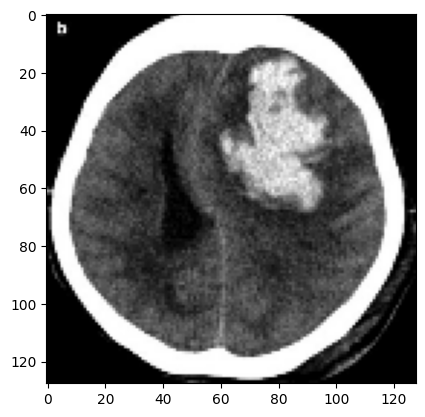

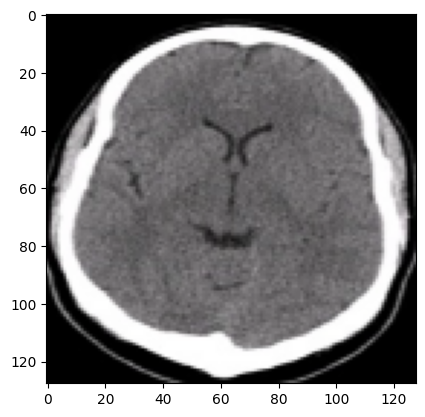

In [ ]:
# plot some images to see
plt.imshow(images[0], cmap=plt.get_cmap('gray'))
plt.show()
plt.imshow(images[110], cmap=plt.get_cmap('gray'))

<Axes: ylabel='count'>

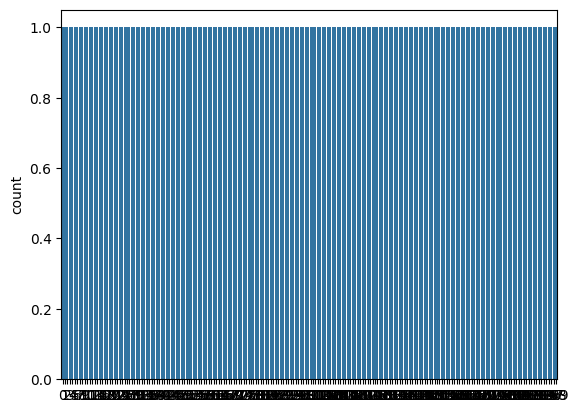

In [ ]:
# look at the distribution of the labels
sns.countplot(labels.hemorrhage) # very balanced

In [ ]:
print(label)  # first hundred all 1, then all 0

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
# take random 60 entries from frist half and then random 60 from the second half for the train set
# to have evenly distributed train, validation, and test sets
indicies = np.random.permutation(100)
a, b = 70, 85
train_true_idx, validation_true_idx, test_true_idx = indicies[:a], indicies[a:b], indicies[b:]
train_false_idx, validation_false_idx, test_false_idx = indicies[:a]+100, indicies[a:b]+100, indicies[b:]+100
train_idx, validation_idx, test_idx = np.append(train_true_idx, train_false_idx), np.append(validation_true_idx, validation_false_idx), np.append(test_true_idx, test_false_idx)

X_train, y_train = images[train_idx], label[train_idx]
X_val, y_val = images[validation_idx], label[validation_idx]
X_test, y_test = images[test_idx], label[test_idx]

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(140, 128, 128, 3) (30, 128, 128, 3) (30, 128, 128, 3)
(140,) (30,) (30,)


In [ ]:
# image augmentation visualization .
data_augmentation = tf.keras.Sequential([layers.RandomFlip("horizontal_and_vertical"), layers.RandomRotation(0.2),])

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

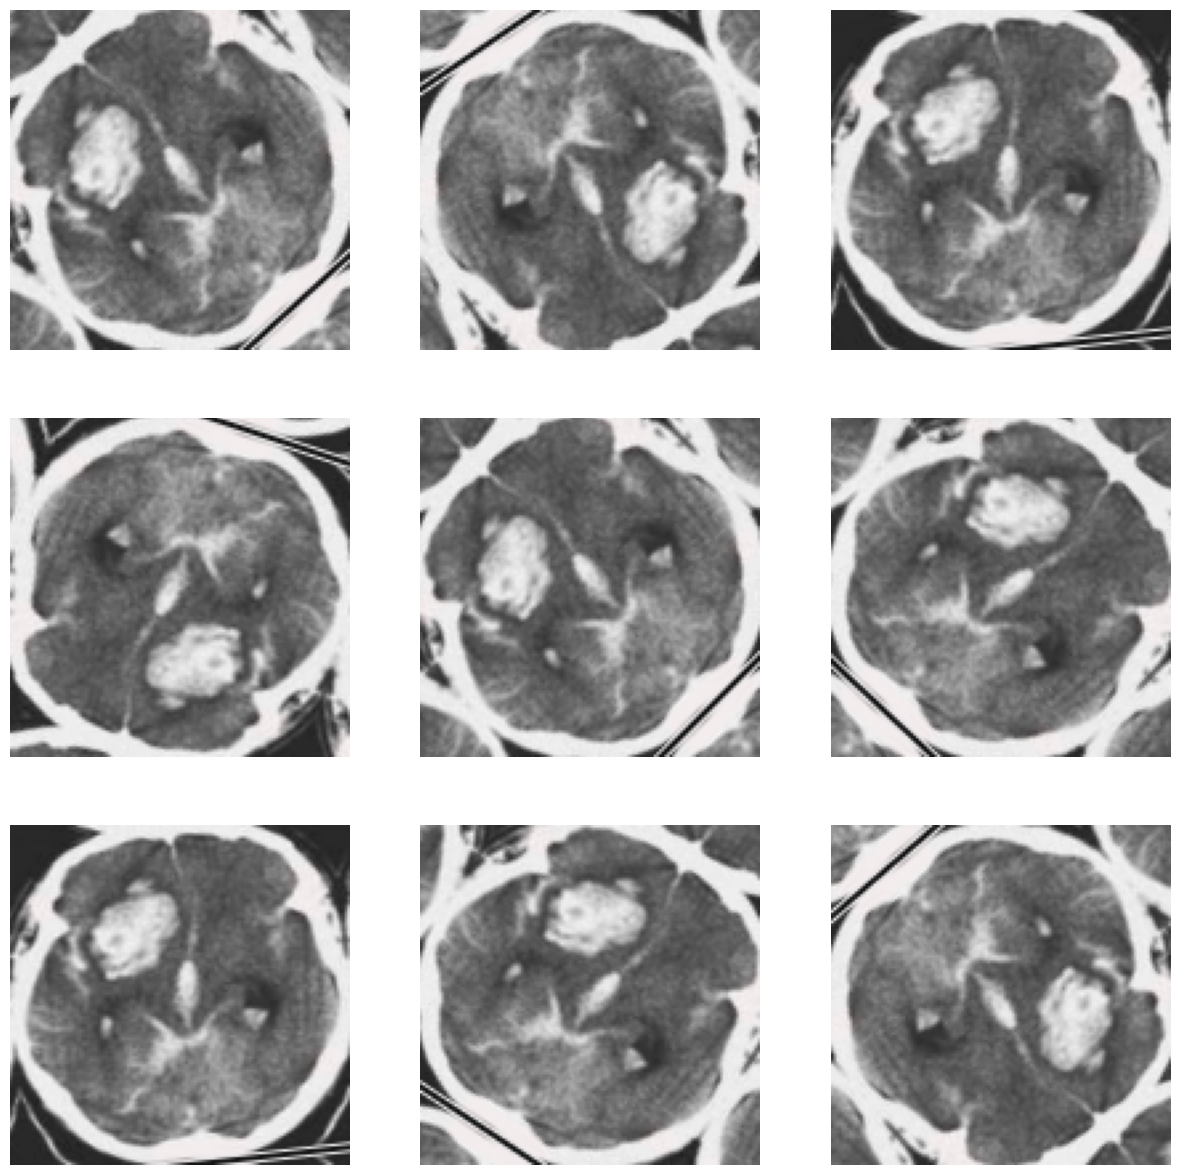

In [ ]:
# Add the image to a batch.
image = tf.cast(tf.expand_dims(images[0], 0), tf.float32)
image = tf.cast(tf.expand_dims(X_train[0], 0), tf.float32)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()
for ax in axes:
  augmented_image = data_augmentation(image)  # , training=True
  ax.imshow(augmented_image[0]/255,)  #  cmap=plt.get_cmap('gray')
  ax.axis("off")
plt.show()

In [ ]:
# image augmentation for train and validation sets
train_image_data = ImageDataGenerator(rescale=1./255, shear_range=0.09, zoom_range=0.2, rotation_range=180, width_shift_range=0.05,
                                      height_shift_range=0.05, horizontal_flip=True, vertical_flip=True, fill_mode='constant', cval=0)
validation_image_data = ImageDataGenerator(rescale=1./255, shear_range=0.09, zoom_range=0.2, rotation_range=90, width_shift_range=0.05,
                                      height_shift_range=0.05, horizontal_flip=True, vertical_flip=True, fill_mode='constant', cval=0)

train_data = train_image_data.flow(X_train, y_train, batch_size=12)
validation_data=validation_image_data.flow(X_val, y_val, batch_size=4)
len(X_train)

140

In [ ]:
#First model: simple CNN

def check_accuracy(model, setX, actual, print_images=True):
    predicted = np.array([int(x[0] > 0.5) for x in model.predict(setX)])
    if print_images:
        rows = math.ceil(len(predicted)/10.)
        plt.figure(figsize=(20, 3 * rows))
        for i in range(len(predicted)):
            plt.subplot(rows, 10, i+1)
            plt.imshow(setX[i])
            plt.title("pred "+str(predicted[i])+" actual "+str(actual[i]))

    confusion = confusion_matrix(actual, predicted)
    tn, fp, fn, tp = confusion.ravel()
    print("True positive:", tp, ", True negative:", tn,
          ", False positive:", fp, ", False negative:", fn)

    print("Total accuracy:", np.sum(predicted==actual) / len(predicted) * 100., "%")
    return (tn, fp, fn, tp)


def simple_conv_model(input_shape):
    model = Sequential()

    model.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'))

    model.add(GlobalAveragePooling2D())
    model.add(Dropout(0.4))

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.4))

    model.add(Dense(1, activation='sigmoid'))
    return model

model = simple_conv_model((128, 128, 3))
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
model.summary()

model.fit(train_image_data.flow(X_train, y_train, batch_size=12), steps_per_epoch=5,
    validation_data=validation_image_data.flow(X_val, y_val, batch_size=4), validation_steps=2,
                    callbacks=[ModelCheckpoint("weights.h5", monitor='val_acc', save_best_only=True, mode='max')], epochs=30)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,753 (120.13 KB)

 Trainable params: 30,753 (120.13 KB)

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.6519 - loss: 0.6902 - val_accuracy: 0.7500 - val_loss: 0.6683
Epoch 27/30
2/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4583 - loss: 0.7104

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.4333 - loss: 0.7075 - val_accuracy: 0.1250 - val_loss: 0.7129
Epoch 28/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.4808 - loss: 0.6864

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.4785 - loss: 0.6876 - val_accuracy: 0.2500 - val_loss: 0.7002
Epoch 29/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4362 - loss: 0.6964

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.4409 - loss: 0.6964 - val_accuracy: 0.5000 - val_loss: 0.6872
Epoch 30/30
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5833 - loss: 0.6964

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4833 - loss: 0.6979 - val_accuracy: 0.6250 - val_loss: 0.6898


In [ ]:
#Second model: Inception

def inceptionv3():
  base_model = InceptionV3(input_shape = (128, 128, 3), include_top = False, weights = 'imagenet')
  for layer in base_model.layers:
    layer.trainable = False

  x = layers.Flatten()(base_model.output)
  x = layers.Dense(1024, activation='relu')(x)
  x = layers.Dropout(0.2)(x)
  # Add a final sigmoid layer with 1 node for classification output
  x = layers.Dense(1, activation='sigmoid')(x)
  model = tf.keras.models.Model(base_model.input, x)
  model.compile(optimizer=RMSprop(learning_rate=0.0001), loss='binary_crossentropy', metrics=['acc'])

  return model

inception_hist = inceptionv3().fit(train_data, validation_data=validation_data, steps_per_epoch=10, epochs=50)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 954ms/step - acc: 0.4944 - loss: 7.2792 - val_acc: 0.7667 - val_loss: 0.6799
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - acc: 0.9083 - loss: 0.2179 - val_acc: 0.8333 - val_loss: 0.4096
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 936ms/step - acc: 0.8246 - loss: 0.6354 - val_acc: 0.6333 - val_loss: 1.9320
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - acc: 0.8250 - loss: 1.4139 - val_acc: 0.8333 - val_loss: 0.3512
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 555ms/step - acc: 0.6888 - loss: 1.3317 - val_acc: 0.5333 - val_loss: 1.7325
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - acc: 0.7792 - loss: 1.0752 - val_acc: 0.8667 - val_loss: 0.4226
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 740ms/step - acc: 0.8072 - loss: 0.8531 - val_acc: 0.8333 - val_loss: 0.8047
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - acc: 0.6750 - loss: 1.9865 - val_acc: 0.7000 - val_loss: 2.2943
Epo

In [ ]:
print("TF:", tf.__version__)
assert 'X_train' in globals() and 'X_val' in globals()

# ---------- Data generators (no rescale; let preprocess_input handle it) ----------
train_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.05, height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True, vertical_flip=True,
    fill_mode='reflect'
)
val_gen = ImageDataGenerator()

batch_size = 12
train_data = train_gen.flow(X_train, y_train, batch_size=batch_size, shuffle=True)
val_data   = val_gen.flow(X_val,   y_val,   batch_size=4, shuffle=False)

# ---------- Optional: class weights if imbalance ----------
pos = np.sum(y_train==1); neg = np.sum(y_train==0)
total = len(y_train)
class_weight = {0: total/(2.0*neg), 1: total/(2.0*pos)}
print("class_weight:", class_weight)

# ---------- Build model with 299x299 input (resize inside model) ----------
def build_xception_model(unfreeze_from=None):
    inp = Input((128,128,3))
    x = Resizing(299, 299, name="resize_to_299")(inp)
    x = Lambda(preprocess_input, name="xception_preprocess")(x)

    base = Xception(include_top=False, weights="imagenet", input_shape=(299,299,3))
    # default: freeze all
    for l in base.layers:
        l.trainable = False

    if unfreeze_from is not None:
        # unfreeze last N layers except BatchNorm (keep BN frozen for small data)
        for l in base.layers[-unfreeze_from:]:
            if not isinstance(l, layers.BatchNormalization):
                l.trainable = True

    x = base(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out)
    return model

os.makedirs("models", exist_ok=True)

# ---------- Stage 1: freeze base, train head ----------
model = build_xception_model(unfreeze_from=None)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

cbs = [
    EarlyStopping(monitor='val_loss', patience=6, min_delta=0.001, restore_best_weights=True, verbose=1),
    ModelCheckpoint('models/xcep_stage1.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, mode='min', verbose=1)
]

print("=== Stage 1: training top ===")
hist1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=cbs,
    class_weight=class_weight,
    verbose=1
)

# ---------- Stage 2: unfreeze last 36 layers for fine-tuning ----------
unfreeze_N = 36
model_ft = build_xception_model(unfreeze_from=unfreeze_N)

# transfer head weights from stage1
for tgt, src in zip(model_ft.layers[::-1], model.layers[::-1]):
    try:
        tgt.set_weights(src.get_weights())
    except Exception:
        pass

model_ft.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                 loss='binary_crossentropy',
                 metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

cbs_ft = [
    EarlyStopping(monitor='val_loss', patience=6, min_delta=0.001, restore_best_weights=True, verbose=1),
    ModelCheckpoint('models/xcep_stage2.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, mode='min', verbose=1)
]

print("=== Stage 2: fine-tuning last", unfreeze_N, "layers ===")
hist2 = model_ft.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=cbs_ft,
    class_weight=class_weight,
    verbose=1
)

# ---------- Final evaluation ----------
vl, va, vauc = model_ft.evaluate(val_data, verbose=1)
print(f"Final VAL -> loss: {vl:.4f} | acc: {va:.4f} | AUC: {vauc:.4f}")


TF: 2.19.0
class_weight: {0: np.float64(1.0), 1: np.float64(1.0)}
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Stage 1: training top ===
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4489 - auc: 0.4951 - loss: 0.7110
Epoch 1: val_loss improved from inf to 0.64714, saving model to models/xcep_stage1.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 73s 6s/step - accuracy: 0.4501 - auc: 0.4929 - loss: 0.7121 - val_accuracy: 0.6000 - val_auc: 0.8356 - val_loss: 0.6471 - learning_rate: 1.0000e-04
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6639 - auc: 0.6575 - loss: 0.6445
Epoch 2: val_loss improved from 0.64714 to 0.59311, saving model to models/xcep_stage1.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 67s 6s/step - accuracy: 0.6634 - auc: 0.6608 - loss: 0.6440 - val_accuracy: 0.8000 - val_auc: 0.9133 - val_loss: 0.5931 - learning_rate: 1.0000e-04
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7217 - auc: 0.8227 - loss: 0.5868
Epoch 3: val_loss improved fro